# SkillPulse — Phase 3: EDA & Feature Engineering

This notebook performs exploratory data analysis on the cleaned job postings,
calibrates salary targets, normalises currencies to USD, constructs a multi-hot
skill feature matrix, and exports the final training artefacts for Phase 4.

## 1. Imports & Aesthetics

In [1]:
import os, re, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from urllib.parse import quote_plus

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.facecolor':'#0f172a','axes.facecolor':'#1e293b',
    'axes.labelcolor':'#cbd5e1','axes.titlecolor':'#f8fafc',
    'xtick.color':'#94a3b8','ytick.color':'#94a3b8',
    'grid.color':'#334155','text.color':'#cbd5e1','figure.dpi':120,
})
TEAL='#0d9488'; AMBER='#f59e0b'
COUNTRY_COLORS={'gb':'#818cf8','in':TEAL,'us':AMBER}
PLOTS_DIR='../eda_plots'; EXPORTS_DIR='../data_exports'
os.makedirs(PLOTS_DIR, exist_ok=True); os.makedirs(EXPORTS_DIR, exist_ok=True)
load_dotenv(dotenv_path='../.env')

True

## 2. Database Connection & Data Load

In [2]:
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{quote_plus(os.getenv('DB_PASSWORD'))}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
df_jobs      = pd.read_sql('SELECT id,country,title,company,salary_min,salary_max FROM job_postings', engine)
df_job_skills= pd.read_sql('SELECT job_id,skill_id FROM job_skills', engine)
df_skills_ref= pd.read_sql('SELECT id,name FROM skills', engine)
print(f'Jobs: {len(df_jobs):,}  |  Job-Skills: {len(df_job_skills):,}  |  Skills: {len(df_skills_ref)}')

Jobs: 18,100  |  Job-Skills: 5,870  |  Skills: 47


## 3. Salary Distribution & USD Standardisation

In [3]:
df_sal = df_jobs.dropna(subset=['salary_min','salary_max']).copy()
df_sal['salary_mid'] = (df_sal['salary_min'].astype(float) + df_sal['salary_max'].astype(float)) / 2

# Fixed historical exchange rates (July 2026)
EXCHANGE = {'gb':1.27,'us':1.00,'in':0.012}
df_sal['salary_usd'] = df_sal.apply(lambda r: r['salary_mid']*EXCHANGE.get(r['country'],1.0), axis=1)

df_sal['log_salary_usd'] = np.log1p(df_sal['salary_usd'])
print(df_sal.groupby('country')[['salary_usd','log_salary_usd']].describe().round(2))

        salary_usd                                                     \
             count       mean       std     min        25%        50%   
country                                                                 
gb          5996.0   85188.37  39733.13    1.27   63500.00   78277.82   
in          2604.0   16051.90  10984.36  120.00    8100.00   13200.00   
us          6000.0  144602.39  45234.74   57.50  110421.68  138099.22   

                             log_salary_usd                                   \
               75%       max          count   mean   std   min    25%    50%   
country                                                                        
gb        96287.56  635000.0         5996.0  11.24  0.71  0.82  11.06  11.27   
in        21000.00   60000.0         2604.0   9.44  0.75  4.80   9.00   9.49   
us       175150.01  393093.4         6000.0  11.83  0.36  4.07  11.61  11.84   

                       
           75%    max  
country                
gb      

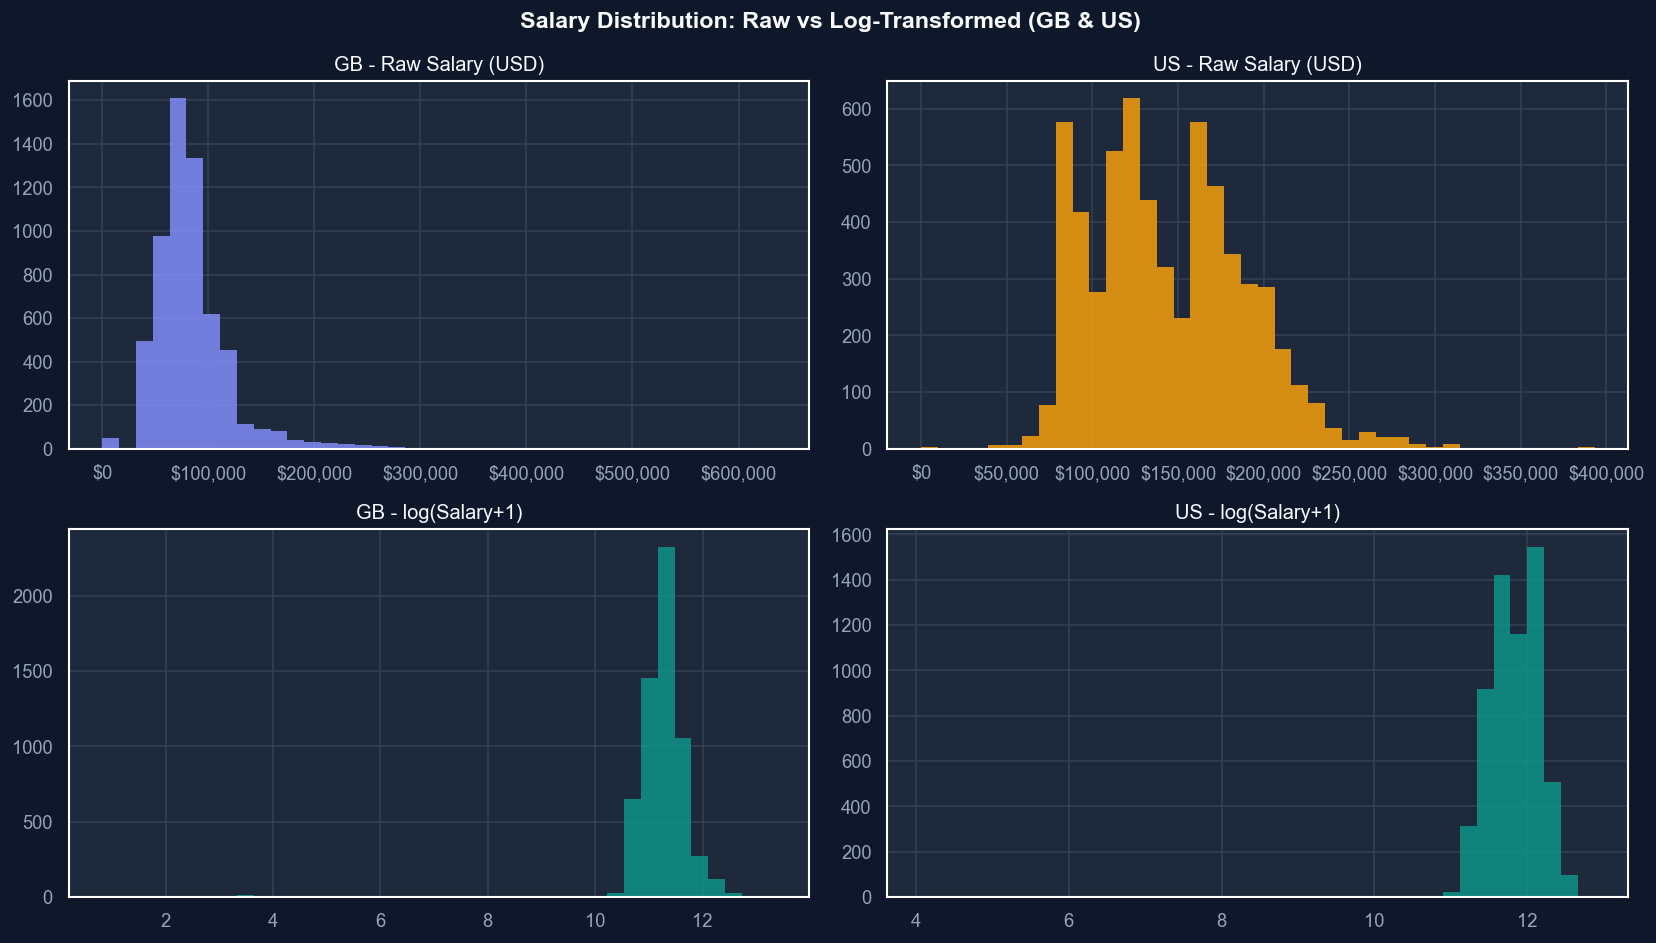

In [4]:
fig, axes = plt.subplots(2,2, figsize=(14,8))
fig.suptitle('Salary Distribution: Raw vs Log-Transformed (GB & US)', fontsize=14, color='#f8fafc', fontweight='bold')
for col, country in enumerate(['gb','us']):
    s  = df_sal[df_sal['country']==country]['salary_usd']
    ls = df_sal[df_sal['country']==country]['log_salary_usd']
    c  = COUNTRY_COLORS[country]
    axes[0,col].hist(s,  bins=40, color=c,    alpha=0.85, edgecolor='none')
    axes[0,col].set_title(f'{country.upper()} - Raw Salary (USD)')
    axes[0,col].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
    axes[1,col].hist(ls, bins=40, color=TEAL, alpha=0.85, edgecolor='none')
    axes[1,col].set_title(f'{country.upper()} - log(Salary+1)')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_salary_distribution.png', bbox_inches='tight')
plt.show()

## 4. Missing Salary Analysis (India)

In [5]:
df_india = df_jobs[df_jobs['country']=='in']
miss_pct = (1 - df_india['salary_min'].notna().sum()/len(df_india))*100
print(f'India missing salary: {miss_pct:.1f}%  -> EXCLUDED from regression training.')

India missing salary: 57.3%  -> EXCLUDED from regression training.


## 5. Top Skills by Country

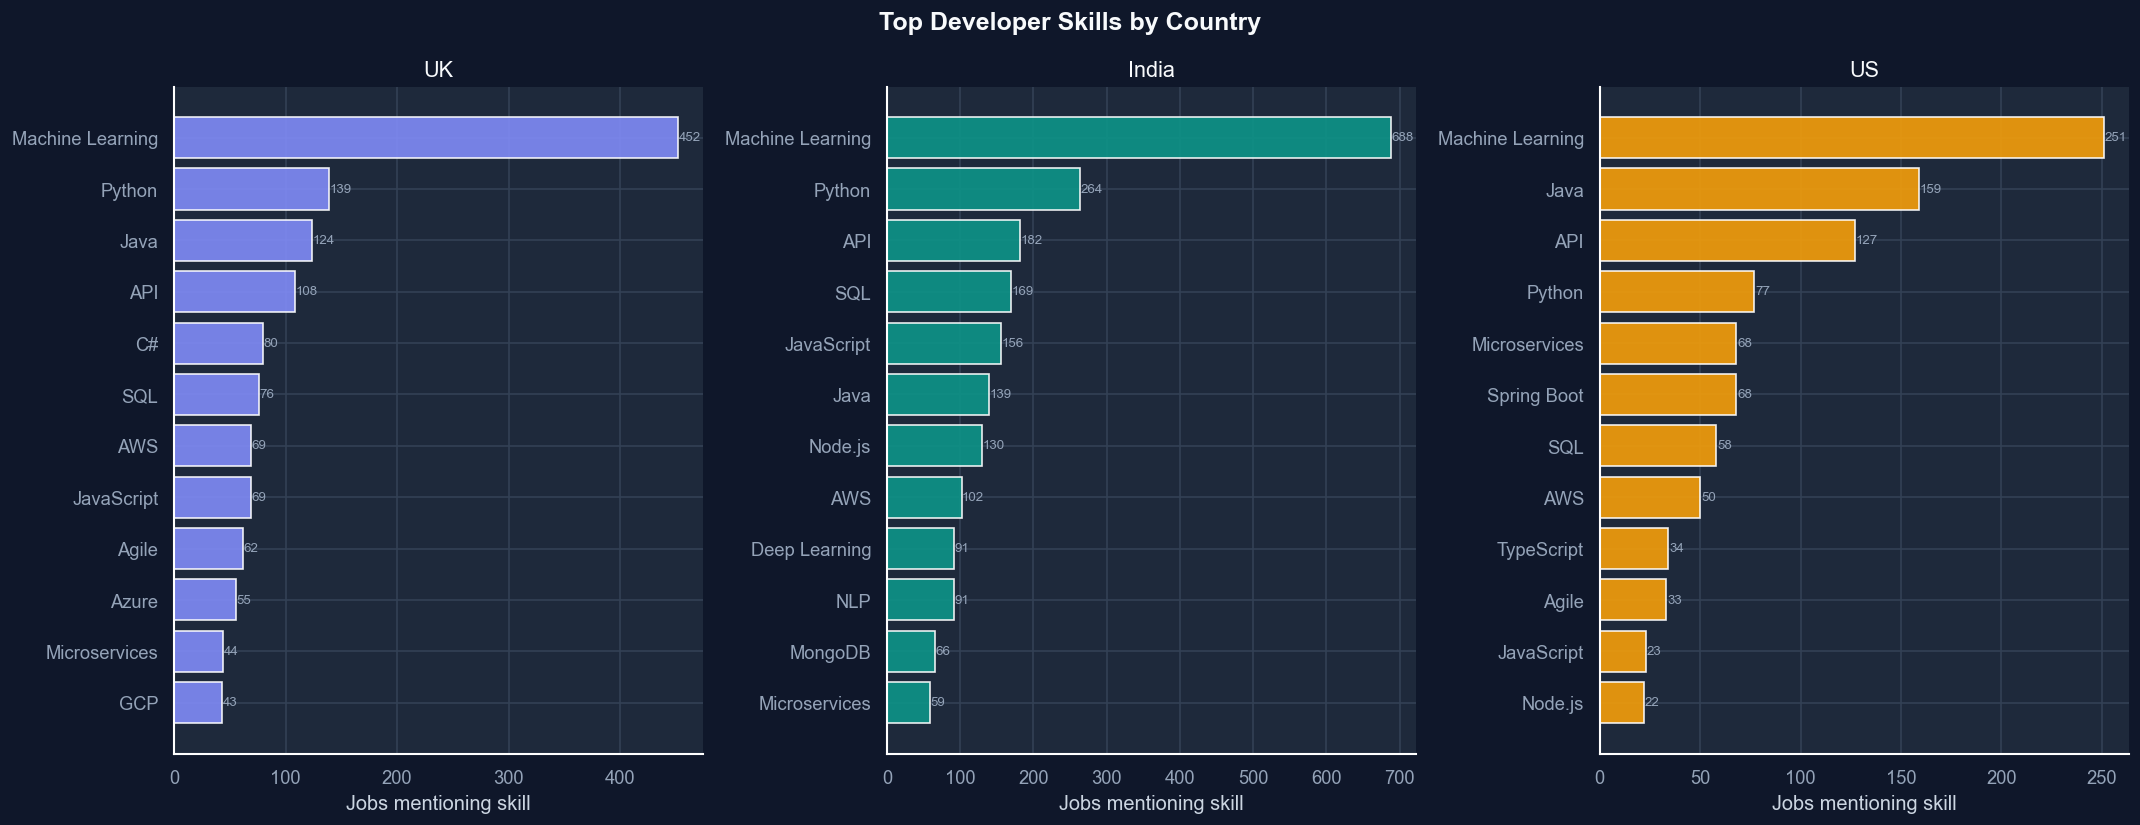

In [6]:
df_merged = (df_job_skills
    .merge(df_skills_ref, left_on='skill_id', right_on='id')
    .merge(df_jobs[['id','country']], left_on='job_id', right_on='id'))

csc = df_merged.groupby(['country','name'])['job_id'].count().reset_index(name='count')

fig, axes = plt.subplots(1,3, figsize=(18,7))
fig.suptitle('Top Developer Skills by Country', fontsize=15, color='#f8fafc', fontweight='bold')
for ax, country in zip(axes,['gb','in','us']):
    top = csc[csc['country']==country].sort_values('count',ascending=False).head(12)
    bars = ax.barh(top['name'][::-1], top['count'][::-1], color=COUNTRY_COLORS[country], alpha=0.9)
    ax.set_title({'gb':'UK','in':'India','us':'US'}[country], fontsize=13)
    ax.set_xlabel('Jobs mentioning skill')
    ax.spines[['top','right']].set_visible(False)
    for bar in bars:
        w = bar.get_width()
        ax.text(w+0.5, bar.get_y()+bar.get_height()/2, f'{int(w)}', va='center', fontsize=8, color='#94a3b8')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_top_skills_by_country.png', bbox_inches='tight')
plt.show()

## 6. Skill Co-occurrence Heatmap

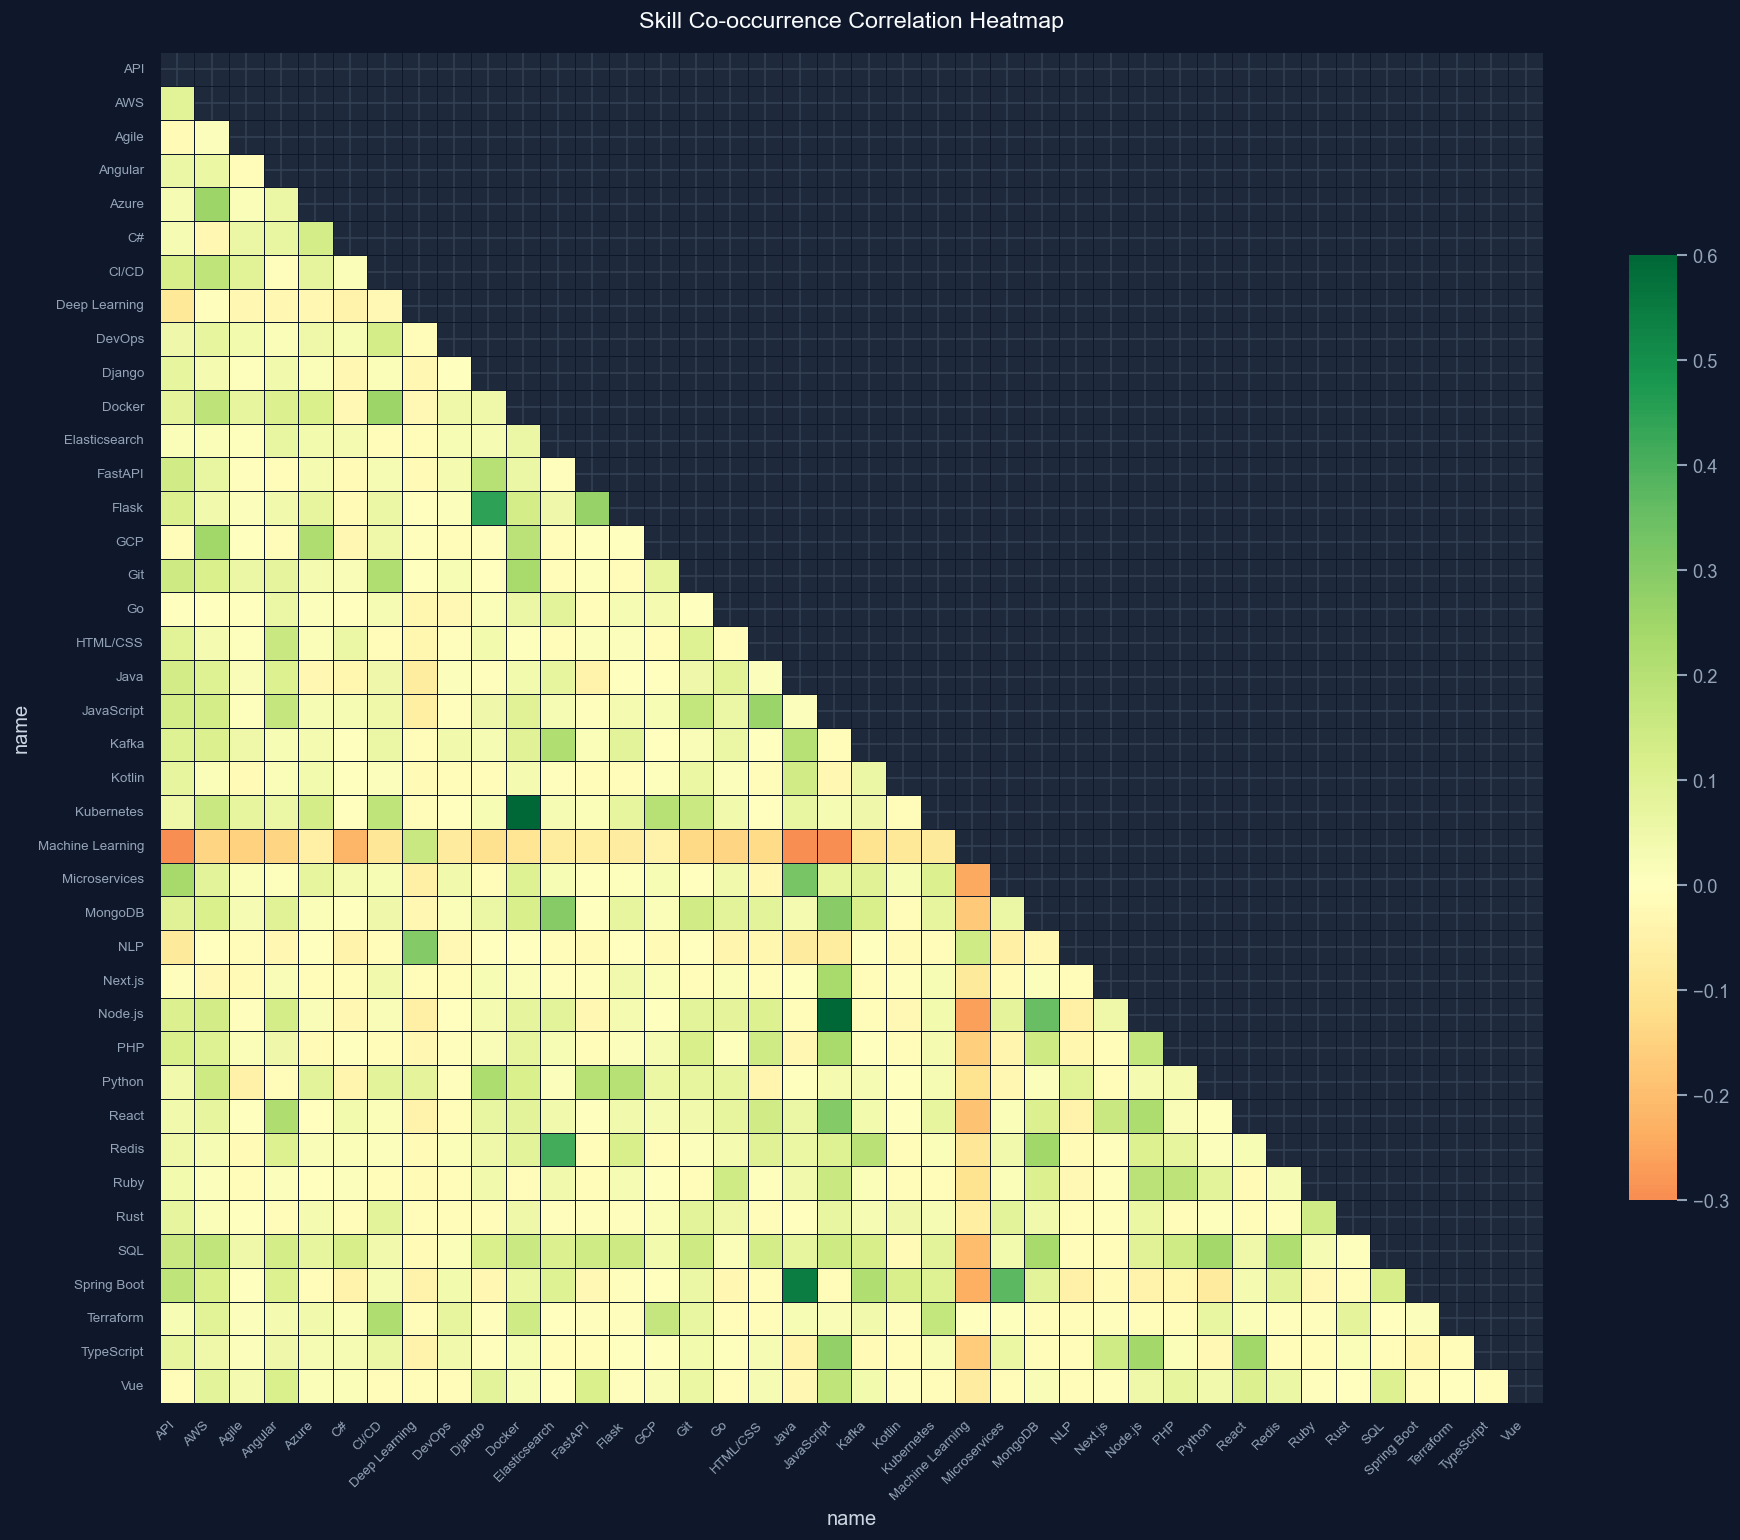

In [7]:
skill_matrix = (
    df_job_skills.merge(df_skills_ref, left_on='skill_id', right_on='id')
    .assign(flag=1)
    .pivot_table(index='job_id', columns='name', values='flag', fill_value=0)
)
popular = skill_matrix.columns[skill_matrix.sum() >= 10]
corr = skill_matrix[popular].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16,13))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn', center=0,
            vmin=-0.3, vmax=0.6, linewidths=0.3, linecolor='#0f172a', ax=ax,
            cbar_kws={'shrink':0.7})
ax.set_title('Skill Co-occurrence Correlation Heatmap', fontsize=14, color='#f8fafc', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_skill_cooccurrence_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Multi-Hot Feature Matrix Construction

In [8]:
df_train = df_sal[df_sal['country'].isin(['gb','us'])].copy()
skill_hot = (
    df_job_skills.merge(df_skills_ref, left_on='skill_id', right_on='id')
    .assign(flag=1)
    .pivot_table(index='job_id', columns='name', values='flag', fill_value=0)
)
X_train = (
    df_train[['id','country','log_salary_usd']]
    .merge(skill_hot.reset_index(), left_on='id', right_on='job_id', how='left')
    .fillna(0)
)
X_train['country_gb'] = (X_train['country']=='gb').astype(int)
X_train['country_us'] = (X_train['country']=='us').astype(int)
y = X_train['log_salary_usd'].values
feat_cols = [c for c in X_train.columns if c not in ['id','job_id','country','log_salary_usd']]
X = X_train[feat_cols].values
print(f'Feature matrix X: {X.shape}  |  Target y: {y.shape}')

Feature matrix X: (11996, 48)  |  Target y: (11996,)


## 8. Export for Phase 4

In [9]:
pd.DataFrame(X, columns=feat_cols).to_csv(f'{EXPORTS_DIR}/X_train.csv', index=False)
pd.DataFrame({'log_salary_usd': y}).to_csv(f'{EXPORTS_DIR}/y_train.csv', index=False)
X_train[['id','country','log_salary_usd']+feat_cols].to_csv(f'{EXPORTS_DIR}/train_full.csv', index=False)
with open(f'{EXPORTS_DIR}/feature_names.json','w') as f:
    json.dump(feat_cols, f, indent=2)
print(f'Exported X({X.shape}), y({y.shape}), train_full, feature_names.json')

Exported X((11996, 48)), y((11996,)), train_full, feature_names.json
